# Getting Started

<h4> This example notebook demonstrates how to operate the CNS Raman system and conduct multidimensional acquisition. Here are a few things you need to do first, </h4>


<h5> 1.  Turn on the laser using the Cobalt Monitor software from the taskbar below. Remember to turn it off after use. </h5>  

<h5> 2.  Apply small amount of water to the objective before placing your sample. If performing long time-lapse, turn on the water pump for continuous hydration. </h5>  

<h5> 3. Run the cells below. </h5>

> a. **Launch Software Control**  
>   - *Note:* If a system restart is required, first try running `core.unloadAllDevices()` if possible. Then, restart the kernel and rerun the notebook. You may need to repeat this process 3–4 times. If the issue persists, sign out of the computer and sign back in (password: graphene).

> b. **Laser Aiming Calibration** (*Recommended when aiming is off*)

> c. **Set up MDA in Napari**

> d. **Set up Raman and Begin Data Acquisition**

> e. **Turn Off Laser and Unload All Devices**

## Setup Napari

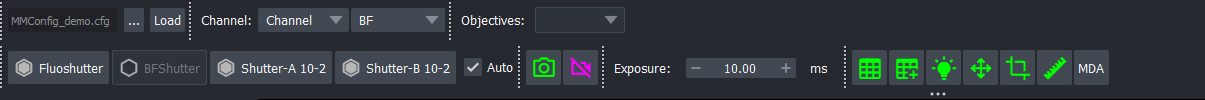

1. Recommended using the stage control to change the z focus 
   <img src="attachment:b6c25591-8626-45d7-9fc7-8b4017f023eb.png" width="20">. Click `poll` under `ZStage`. Change the step size accordingly and start finding the right focus
   
<img src="attachment:efeff874-ea7c-4598-a4e4-49191128f9b1.png" width="400">

2. To setup MDA, click the `MDA` button on the upper right. Remember to change the axis order to `tpcz`.

# Launch Software Control

In [ ]:
%matplotlib widget 

import sys
from PyQt5.QtWidgets import QApplication

if not QApplication.instance(): # this is required to suppress warnings from QObject
    app = QApplication(sys.argv)
    
from napari import Viewer
from pymmcore_plus import CMMCorePlus
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from tqdm.notebook import trange, tqdm
from cns_control.utils import add_mask_with_hole, create_point_sources, filter_mean, set_up_new_seq, automated_point_selections, unload
from cns_control.autofocus import autofocus_w_bkd, autofocus_w_raman
from cns_control.coordtransformer import *
from cns_control.calibration import *
from raman_control.andor import *
from raman_mda_engine.aiming import (
    PointsLayerSource,
    ShapesLayerSource,
    SimpleGridSource,
)
from napari_broadcastable_points import BroadcastablePoints
from raman_mda_engine.aiming.transformers import Circle, Square
from raman_mda_engine import RamanEngine, RamanTiffAndNumpyWriter
from raman_mda_engine.utils import get_seq_from_napari

core = CMMCorePlus.instance()
core.loadSystemConfiguration("test3.cfg")
try:
    core.setConfig("Channel", "GFP")
    time.sleep(1)
              
    core.setConfig("Channel", "BF")
except:
    RuntimeError

v = Viewer()
dw, main_window = v.window.add_plugin_dock_widget("napari-micromanager")
transformer = CoordTransformer.from_json("model_2026-01-08.json")
default_engine = core.mda.engine

In [ ]:
collector = AndorSpectraCollector()
daq = collector.daq

In [ ]:
# unload(core) # run if need to restart notebook

# Preliminary check of the Raman spectrum

1. Choose the Raman channel
2. Turn on live-mode
3. Click `new points layer` on the left
4. Add a point on the FOV to where you want the laser to aim 

In [ ]:
daq.galvo.stop()
daq.galvo.start()
exposurse = 5000 # in ms
N = 2 # number of repeated measurements

pt = v.layers[-1].data[0, -2:]
shape = v.layers[-1].data.shape
Y, X = shape[-2], shape[-1]

volts = transformer.BF_to_volts((pt.reshape(1, -1))/[Y, X], max_volts=1.8)
spec = collector.collect_spectra_pts(np.tile(volts[0], (N, 1)), exposure)

plt.figure()
_ = plt.plot(filter_mean(spec))
plt.xlabel('Pixels')
plt.ylabel('Intensity (a.u.)')
plt.title('Dark Noise');

If the laser is misaligned from the set position, then run the `Laser aiming calibration` below.

# Laser Aiming Calibration

Use the joystick or stage control to go to a position where there is just background. Then change the channel to `RM` (set exposure to 1-10ms) and adjust the z focus using the stage control to focus the laser.

In [ ]:
transformer = CoordTransformer.from_json("model_2026-01-08.json")

In [ ]:
calibrator = Calibrator(core, daq, transformer, collector, N=20, exp=5000, max_volts=1.8)

In [ ]:
ds = calibrator.calibrate(10, thres=1.0) # increase this number for denser grids

## Recalibration (*only if aiming is off*)

In [ ]:
selector = ManualImageSelector(ds)
selected_points = selector.start()

In [ ]:
model_name = 'model_2026-01-08'
_ = calibrator.save_new_model(ds, selected_points, model_name)
transformer = CoordTransformer.from_json(f"{model_name}.json")

# Collect Reference Spectra

Collect axial Raman scans on cell-free regions
1. Use joystick to move to a place with no cells
2. Use the points layer to add a point indicating where the reference spectra will be collected.

In [ ]:
from cns_control.autofocus import autofocus_w_bkd

import uuid
uuid1 = uuid.uuid1()
name = 'testing'
exp = 1000 # in ms
N = 20 # number of spectra
search_range = 10
search_pts = 20
pt = v.layers[-1].data[0, -2:]
shape = v.layers[-1].data.shape
Y, X = shape[-2], shape[-1]
volts = transformer.BF_to_volts((pt.reshape(1, -1))/[Y, X], max_volts=1.8)
focusZ, coarse_raman, all_raman = autofocus_w_bkd(core, daq, collector, np.array([volts[0] for _ in range(N)]), search_range=search_range, search_pts=search_pts, exposure=exp, plot=False)
core.setZPosition(focusZ)
plt.figure()
zs = np.linspace(-search_range, search_range, search_pts)
for i in range(zs.shape[0]):
    plt.plot(filter_mean(all_raman[i]), label=f'z={round(zs[i])}um')
plt.xlabel('Pixels')
plt.ylabel('Intensity (a.u.)')
plt.legend();

np.save(f'reference/reference_spec_zs_{name}.npy', zs)
np.save(f'reference/reference_spec_{exp}s_{name}.npy', all_raman)
np.save(f'reference/reference_spec_xy_{name}.npy', pt)

# Spatial Mapping

Add a `new shapes layer` from the left. Draw a rectangle around the region of interest. Arbitrary shapes can also be used, provided the code below is modified accordingly.

In [ ]:
def grid_scan(exp=1000, N=20, z_offset=4):
    shapes = v.layers[-1]
    x_min = np.min(shapes.data[0][:, 0])
    x_max = np.max(shapes.data[0][:, 0])
    y_min = np.min(shapes.data[0][:, 1])
    y_max = np.max(shapes.data[0][:, 1])
    x = np.linspace(x_min, x_max, N)
    y = np.linspace(y_min, y_max, N)
    X, Y = np.meshgrid(x, y)
    grid = np.column_stack([X.ravel(), Y.ravel()])

    core.setConfig("Channel", "BF")
    core.setExposure(10)
    BF = core.snap()


    core.setConfig("Channel", "GFP")
    core.setExposure(500)
    GFP = core.snap()

    core.setConfig("Channel", "mCherry")
    core.setExposure(1000)
    mCherry = core.snap()

    daq.galvo.stop()
    daq.galvo.start()
    currentz = core.getPosition()
    core.setPosition(currentz - z_offset)
    core.setConfig("Channel", "RM")
    core.setShutterOpen("Fluoshutter", True)

    volts = transformer.BF_to_volts(grid/[1024, 1344], max_volts=1.8)
    core.stopSequenceAcquisition()
    core.setExposure(1)
    specs = collector.collect_spectra_pts(volts, exp)
    core.setShutterOpen("Fluoshutter", False)

    core.setPosition(currentz)
    core.setConfig("Channel", "BF")
    core.setExposure(10)
    end_BF = core.snap()

    ds = xr.Dataset(
        {
            "laser_pos": xr.DataArray(volts, dims=("idx", "volt")),
            "grid_pos": xr.DataArray(grid, dims=("idx", "volt")),
            "specs": xr.DataArray(specs, dims=("N", "spec_dim")),
            "BF": xr.DataArray(BF, dims=("Y", "X")),
            "end_BF": xr.DataArray(end_BF, dims=("Y", "X")),
            "GFP": xr.DataArray(GFP, dims=("Y", "X")),
            "mCherry": xr.DataArray(mCherry, dims=("Y", "X"))
        }
        )

    import uuid
    from datetime import datetime

    ds.attrs["time"] = str(datetime.now())
    z = uuid.uuid4().hex
    name = f"grid_scan_data_{z}.zarr"
    ds.to_zarr(name)
    print(f"Saved calibration dataset to {name}")

    return ds

In [ ]:
ds = grid_scan(exp=1000, N=int(np.sqrt(8*3600)), z_offset=0)

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(10, 4), sharex=True, sharey=True)
ax[0].imshow(ds['BF'].values)
ax[1].imshow(ds['end_BF'].values)
ax[2].imshow(ds['GFP'].values)
ax[3].imshow(ds['mCherry'].values)
plt.tight_layout()

In [ ]:
plt.figure()
plt.plot(np.mean(ds['specs'].values, axis=0))

# Set up MDA

In [ ]:
add_mask_with_hole(
    v,
    image_size=(1024, 1344),
    circle_center=(540, 740),
    circle_radius=100,
    small_circle_radius=10,
    color=(255, 0, 0),
    alpha=60,
    small_circle_color=(0, 255, 0),  # green marker dot
    small_circle_alpha=255
)


Cells to be imaged can be selected either manually or automatically.

## Manual Selection

Go to **Napari**, select the respective point layers and add the points accordingly for each position. Recommended to select points within the inner circular region. 

In [ ]:
point_transformer = Square(0.002, 2)
point_transformer.multiplier
# sources = create_point_sources(v, point_transformer, size=15)

Open up **Napari** to setup MDA sequence (for more information navigate to `Getting Started`). After setting up the MDA sequence, change the number of loops to 2, then click `Run` for a short MDA without Raman. Remember to change the axis order to `tpcz` and stop `live mode` before running. 

## Automated Selection

In [ ]:
core.register_mda_engine(default_engine)
batch = False # integrated batch selection
autofocus_object = 'laser' # 'cell', 'quartz', 'glass', 'software', 'laser'
N_per_fov = 6
point_transformer = Square(0.002, 1)
center = (540, 740)
radius = 100
sources, autofocus_p, new_seq = automated_point_selections(core, v, main_window, point_transformer, N=N_per_fov+1, center=center, radius=radius, autofocus_object=autofocus_object, bkd_thres=80, batch=batch)

# Set up Raman

In [ ]:
raman_offset = 5.0
engine = RamanEngine(spectra_collector=collector, scale=2,transformer=transformer, batch=batch, autofocus_p=autofocus_p, autofocus_object=autofocus_object, raman_glass_offset=raman_offset, autofocus_search_range=40, skip_imaging_for_same_pos=True)
core.register_mda_engine(engine)
writer =  RamanTiffAndNumpyWriter("data/run")
engine.aiming_sources = sources
engine._autofocus_search_range = 4.5

In [ ]:
if batch:
    final_seq = set_up_new_seq(main_window, point_transformer, engine, seq=new_seq, total_exposure=10000, batch=batch, z_plan='middle')
else:
    final_seq = set_up_new_seq(main_window, point_transformer, engine, seq=new_seq, total_exposure=10000*point_transformer.multiplier, batch=batch, z_plan='middle')

In [ ]:
import datetime
from useq import ZRangeAround
from useq import ZRelativePositions

new_time_plan = final_seq.time_plan.replace(
    loops=100,
    interval=datetime.timedelta(seconds=600)
)

new_z_plan = ZRelativePositions(relative=[0.0, 3.33])

gfp_channel = final_seq.channels[0].replace(config='GFP', exposure=10) # add fluorescence channels

final_seq = final_seq.replace(axis_order=('t', 'p', 'c', 'z'), time_plan=new_time_plan, z_plan=new_z_plan, channels=final_seq.channels + (gfp_channel, ))
final_seq.metadata["raman"]['z'] = [0] # indices of the z-planes for Raman data collection

In [ ]:
final_seq

In [ ]:
core.run_mda(final_seq)